# CS 598: Project 4 - Code

This notebook contains all of the code and analysis done for this project.

In [36]:
import pandas as pd 

# Read in the data 
df_test = pd.read_csv("data/fashion-mnist_test.csv")
df_train = pd.read_csv("data/fashion-mnist_train.csv")

In [37]:
# Check the data shape to make sure they are what is expected
print("test data shape:", df_test.shape)
print("train data shape:", df_train.shape)

test data shape: (10000, 785)
train data shape: (60000, 785)


In [38]:
# PReview the data
df_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Data Preprocessing

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Separate features and labels
X_train = df_train.iloc[:, 1:].values  
y_train = df_train.iloc[:, 0].values   

X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

print("Feature shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Feature shapes:
X_train shape: (60000, 784)
X_test shape: (10000, 784)
y_train shape: (60000,)
y_test shape: (10000,)


In [40]:
# Step 2: Normalize pixel values from [0, 255] to [0, 1]
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

print("\nNormalization check:")
print(f"X_train min: {X_train_normalized.min()}, max: {X_train_normalized.max()}")
print(f"X_test min: {X_test_normalized.min()}, max: {X_test_normalized.max()}")


Normalization check:
X_train min: 0.0, max: 1.0
X_test min: 0.0, max: 1.0


In [ ]:
# Step 3: Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normalized)
X_test_scaled = scaler.transform(X_test_normalized)

print("\nStandardization check:")
print(f"X_train_scaled mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"X_test_scaled mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")


Standardization check:
X_train_scaled mean: 0.000000, std: 1.000000
X_test_scaled mean: 0.002033, std: 1.009420


In [ ]:
# Step 4: Apply PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nPCA Dimensionality Reduction:")
print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of features after PCA: {X_train_pca.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")

# Save the preprocessed data for later use
preprocessed_data = {
    'X_train_scaled': X_train_scaled,
    'X_test_scaled': X_test_scaled,
    'X_train_pca': X_train_pca,
    'X_test_pca': X_test_pca,
    'y_train': y_train,
    'y_test': y_test,
    'scaler': scaler,
    'pca': pca
}


PCA Dimensionality Reduction:
Original number of features: 784
Number of features after PCA: 256
Variance explained: 0.9502
X_train_pca shape: (60000, 256)
X_test_pca shape: (10000, 256)


## 1) Data Processing and Unsupervised Learning

### 1a. Compute a frequency table of the outcome variable in both training and testing data.

In [43]:
# Class labels mapping
class_labels = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

# Compute frequency tables
train_freq = pd.Series(y_train).value_counts().sort_index()
test_freq = pd.Series(y_test).value_counts().sort_index()

# Create a comprehensive frequency table
frequency_table = pd.DataFrame({
    'Class': [class_labels[i] for i in range(10)],
    'Train Count': [train_freq[i] for i in range(10)],
    'Test Count': [test_freq[i] for i in range(10)]
})

# Add percentages
frequency_table['Train %'] = (frequency_table['Train Count'] / frequency_table['Train Count'].sum() * 100).round(2)
frequency_table['Test %'] = (frequency_table['Test Count'] / frequency_table['Test Count'].sum() * 100).round(2)

print("Frequency Table of Outcome Variable (Class Labels)")
print("=" * 70)
print(frequency_table.to_string(index=False))
print("=" * 70)
print(f"\nTotal Training Samples: {frequency_table['Train Count'].sum()}")
print(f"Total Testing Samples: {frequency_table['Test Count'].sum()}")

Frequency Table of Outcome Variable (Class Labels)
      Class  Train Count  Test Count  Train %  Test %
T-shirt/top         6000        1000     10.0    10.0
    Trouser         6000        1000     10.0    10.0
   Pullover         6000        1000     10.0    10.0
      Dress         6000        1000     10.0    10.0
       Coat         6000        1000     10.0    10.0
     Sandal         6000        1000     10.0    10.0
      Shirt         6000        1000     10.0    10.0
    Sneaker         6000        1000     10.0    10.0
        Bag         6000        1000     10.0    10.0
 Ankle boot         6000        1000     10.0    10.0

Total Training Samples: 60000
Total Testing Samples: 10000


- This is a perfectly balanced dataset. Each class has exactly 6000 samples in the training and 1000 in testing. 
- There's equal distribution - each class represents 10% of both datasets
- All 10 classes represented 



### 1b. Perform two clustering algorithms to the training data



In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Use PCA-reduced data for clustering to improve computational efficiency
X_train_clustering = X_train_pca

# Silhouette Statistic Method

silhouette_scores = []
K_range = range(2, 16)

print("Computing Silhouette Scores for k = 2 to 15...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train_clustering)
    score = silhouette_score(X_train_clustering, cluster_labels)
    silhouette_scores.append(score)
    print(f"  k = {k:2d}: Silhouette Score = {score:.4f}")

optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
max_silhouette = max(silhouette_scores)

print(f"\n✓ OPTIMAL k by Silhouette Score: {optimal_k_silhouette} (score: {max_silhouette:.4f})")



Computing Silhouette Scores for k = 2 to 15...
  k =  2: Silhouette Score = 0.1733
  k =  3: Silhouette Score = 0.1447
  k =  4: Silhouette Score = 0.1510
  k =  5: Silhouette Score = 0.1316
  k =  6: Silhouette Score = 0.1319
  k =  7: Silhouette Score = 0.1441
  k =  8: Silhouette Score = 0.1487
  k =  9: Silhouette Score = 0.1488
  k = 10: Silhouette Score = 0.1375
  k = 11: Silhouette Score = 0.1329
  k = 12: Silhouette Score = 0.1293
  k = 13: Silhouette Score = 0.1297
  k = 14: Silhouette Score = 0.1267
  k = 15: Silhouette Score = 0.1194

✓ OPTIMAL k by Silhouette Score: 2 (score: 0.1733)


In [60]:
# Gap Statistic Method

def compute_gap_statistic(X, K_range, n_refs=10, random_state=42):
    """
    Compute Gap Statistic for determining optimal number of clusters.
    """
    np.random.seed(random_state)
    gaps = []
    sks = []
    
    for k in K_range:
        # Cluster the actual data
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        actual_labels = kmeans.fit_predict(X)
        
        # Calculate within-cluster variance for actual data
        actual_dispersion = 0
        for i in range(k):
            cluster_points = X[actual_labels == i]
            if len(cluster_points) > 0:
                centroid = cluster_points.mean(axis=0)
                actual_dispersion += np.sum((cluster_points - centroid) ** 2)
        
        # Generate reference (random) data and calculate dispersion
        ref_dispersions = []
        for _ in range(n_refs):
            # Generate random uniform data with same bounds as actual data
            random_data = np.random.uniform(X.min(), X.max(), X.shape)
            
            kmeans_ref = KMeans(n_clusters=k, random_state=42, n_init=10)
            ref_labels = kmeans_ref.fit_predict(random_data)
            
            ref_dispersion = 0
            for i in range(k):
                cluster_points = random_data[ref_labels == i]
                if len(cluster_points) > 0:
                    centroid = cluster_points.mean(axis=0)
                    ref_dispersion += np.sum((cluster_points - centroid) ** 2)
            ref_dispersions.append(np.log(ref_dispersion))
        
        # Gap = E[log(W_ref)] - log(W_actual)
        gap = np.mean(ref_dispersions) - np.log(actual_dispersion)
        gaps.append(gap)
        
        # Standard deviation of reference dispersions
        sk = np.std(ref_dispersions) * np.sqrt(1 + 1/n_refs)
        sks.append(sk)
    
    return np.array(gaps), np.array(sks)

gaps, sks = compute_gap_statistic(X_train_clustering, K_range, n_refs=10)

# Find optimal k using the gap statistic rule
optimal_k_gap = None
for i in range(len(gaps) - 1):
    if gaps[i] >= gaps[i + 1] - sks[i + 1]:
        optimal_k_gap = list(K_range)[i]
        break

if optimal_k_gap is None:
    optimal_k_gap = list(K_range)[np.argmax(gaps)]

print("\nGap Statistic values:")
for k, gap, sk in zip(K_range, gaps, sks):
    print(f"  k = {k:2d}: Gap = {gap:.4f}, s(k) = {sk:.4f}")

print(f"\n✓ OPTIMAL k by Gap Statistic: {optimal_k_gap} (Gap: {gaps[optimal_k_gap - 2]:.4f})")




Gap Statistic values:
  k =  2: Gap = 7.2116, s(k) = 0.0001
  k =  3: Gap = 7.3244, s(k) = 0.0001
  k =  4: Gap = 7.4142, s(k) = 0.0002
  k =  5: Gap = 7.4637, s(k) = 0.0002
  k =  6: Gap = 7.5116, s(k) = 0.0001
  k =  7: Gap = 7.5619, s(k) = 0.0002
  k =  8: Gap = 7.5921, s(k) = 0.0002
  k =  9: Gap = 7.6224, s(k) = 0.0002
  k = 10: Gap = 7.6485, s(k) = 0.0002
  k = 11: Gap = 7.6732, s(k) = 0.0001
  k = 12: Gap = 7.6962, s(k) = 0.0002
  k = 13: Gap = 7.7139, s(k) = 0.0002
  k = 14: Gap = 7.7284, s(k) = 0.0002
  k = 15: Gap = 7.7431, s(k) = 0.0003

✓ OPTIMAL k by Gap Statistic: 15 (Gap: 7.7431)


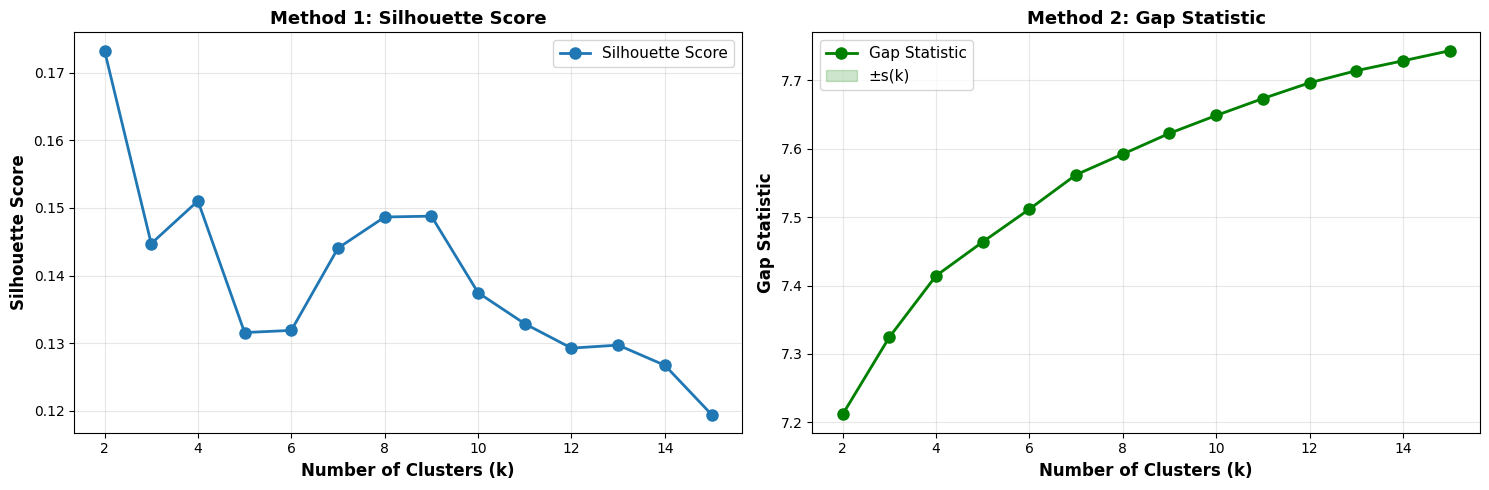

In [61]:
# Visualization of Results

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Silhouette Score
axes[0].plot(K_range, silhouette_scores, 'o-', linewidth=2, markersize=8, label='Silhouette Score')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[0].set_title('Method 1: Silhouette Score', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Plot 2: Gap Statistic
axes[1].plot(K_range, gaps, 'o-', linewidth=2, markersize=8, color='green', label='Gap Statistic')
axes[1].fill_between(K_range, gaps - sks, gaps + sks, alpha=0.2, color='green', label='±s(k)')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Gap Statistic', fontsize=12, fontweight='bold')
axes[1].set_title('Method 2: Gap Statistic', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

In [46]:
# Refit with optimal k = 2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_assignments = kmeans_final.fit_predict(X_train_clustering)

# Analyze each cluster
cluster_analysis = pd.DataFrame({
    'True_Label': [class_labels[y] for y in y_train],
    'Cluster': cluster_assignments
})

for cluster_id in range(2):
    cluster_data = cluster_analysis[cluster_analysis['Cluster'] == cluster_id]
    label_counts = cluster_data['True_Label'].value_counts()
    
    dominating_label = label_counts.idxmax()
    dominating_count = label_counts.max()
    cluster_size = len(cluster_data)
    purity = dominating_count / cluster_size
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {cluster_size}")
    print(f"  Dominating Label: {dominating_label}")
    print(f"  Purity: {purity*100:.2f}%")
    print(f"  Top 5 Labels:")
    print(label_counts.head())

avg_purity = np.mean([cluster_analysis[cluster_analysis['Cluster'] == i]['True_Label'].value_counts().max() / len(cluster_analysis[cluster_analysis['Cluster'] == i]) for i in range(2)])
print(f"\nAverage Purity: {avg_purity*100:.2f}%")
print(f"Baseline (random): 10.00%")


Cluster 0:
  Size: 28823
  Dominating Label: Sneaker
  Purity: 20.81%
  Top 5 Labels:
True_Label
Sneaker       5999
Sandal        5978
Ankle boot    5419
Bag           3597
Shirt         1762
Name: count, dtype: int64

Cluster 1:
  Size: 31177
  Dominating Label: Coat
  Purity: 17.02%
  Top 5 Labels:
True_Label
Coat           5307
Trouser        4750
T-shirt/top    4714
Pullover       4598
Dress          4563
Name: count, dtype: int64

Average Purity: 18.92%
Baseline (random): 10.00%


## 2) Multi-class Classification Model 

Choose 4 multi-class classification methods from class: 

### Method 1: Logistic Regression



In [47]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [50]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print(f"\nResults:")
print(f"  Accuracy:  {lr_accuracy:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall:    {lr_recall:.4f}")
print(f"  F1-Score:  {lr_f1:.4f}")


Results:
  Accuracy:  0.8446
  Precision: 0.8432
  Recall:    0.8446
  F1-Score:  0.8436


### Method 2: SVM with Gaussian kernel

In [52]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    verbose=0
)
svm_model.fit(X_train_pca, y_train)

y_pred_svm = svm_model.predict(X_test_pca)

# Metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_recall = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print(f"\nResults:")
print(f"  Accuracy:  {svm_accuracy:.4f}")
print(f"  Precision: {svm_precision:.4f}")
print(f"  Recall:    {svm_recall:.4f}")
print(f"  F1-Score:  {svm_f1:.4f}")



Results:
  Accuracy:  0.8943
  Precision: 0.8935
  Recall:    0.8943
  F1-Score:  0.8935


### Method 3: Gradient Boosting

In [58]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=1
)
gb_model.fit(X_train_pca, y_train)

y_pred_gb = gb_model.predict(X_test_pca)

# Metrics
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_model_precision = precision_score(y_test, y_pred_gb, average='weighted', zero_division=0)
gb_recall = recall_score(y_test, y_pred_gb, average='weighted', zero_division=0)
gb_f1 = f1_score(y_test, y_pred_gb, average='weighted', zero_division=0)


print(f"\nResults:")
print(f"  Accuracy:  {gb_accuracy:.4f}")
print(f"  Precision: {gb_model_precision:.4f}")
print(f"  Recall:    {gb_recall:.4f}")
print(f"  F1-Score:  {gb_f1:.4f}")

      Iter       Train Loss   Remaining Time 
         1           1.7665           49.71m
         2           1.4995           48.72m
         3           1.3147           48.03m
         4           1.1744           46.94m
         5           1.0639           45.95m
         6           0.9730           44.90m
         7           0.8977           43.86m
         8           0.8340           42.82m
         9           0.7791           41.85m
        10           0.7325           48.13m
        20           0.4760           36.88m
        30           0.3733           24.92m
        40           0.3181           24.62m
        50           0.2814            0.00s

Results:
  Accuracy:  0.8575
  Precision: 0.8561
  Recall:    0.8575
  F1-Score:  0.8563


### Method 4: Random Forest

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"\nResults:")
print(f"  Accuracy:  {rf_accuracy:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall:    {rf_recall:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")




Results:
  Accuracy:  0.8774
  Precision: 0.8763
  Recall:    0.8774
  F1-Score:  0.8756
